Modèles épidémiologiques et simulation d'épidémies (https://en.wikipedia.org/wiki/Compartmental_models_(epidemiology))
## 1.Modèle SIR. Prévision épidémique, maths appliqué

Le modèle SIR suppose que la population totale $N$ est composée de trois catégories de personnes :

- les **susceptibles** $S(t)$ : individus pouvant être infectés,
- les **infectés** $I(t)$ : individus actuellement contaminés,
- les **retirés** $R(t)$ : individus ne pouvant plus être infectés (guéris ou décédés).

Ainsi, la population totale vérifie :
$$
N = S(t) + I(t) + R(t)
$$

Les individus évoluent entre ces compartiments selon les flux suivants :

- Les susceptibles deviennent infectés (processus d'**infection**),
- Les infectés deviennent retirés (processus de **guérison** ou retrait).

On peut représenter ces transitions par le schéma :

$$
S \;\xrightarrow{\text{infection}}\; I \;\xrightarrow{\text{guérison}}\; R
$$

Nous cherchons à décrire l'évolution dans le temps des effectifs dans chaque compartiment.  
Cela conduit à modéliser le système à l'aide d'équations différentielles ordinaires dépendant du temps.

### 1.1 Variation sur $S$

Les personnes susceptibles cessent de l'être lorsqu'elles migrent vers le stade d'infection.  
On les retire du compartiment proportionnellement à $S$ et à $I$ avec un taux de contamination $\beta$.

$$
\frac{dS}{dt} = -\beta S I
$$

Si $S$ et $I$ sont exprimés en effectifs (nombre de personnes), alors la dérivée $\frac{dS}{dt}$ s'exprime en $\frac{\text{personnes}}{\text{jour}}$.

Le paramètre $\beta$ doit donc avoir pour unité :
$$
\frac{1}{\text{personne} \cdot \text{jour}}
$$

Plus $\beta$ est élevé, plus l'infection se propage rapidement.

### 1.2 Variation sur $I$

L'effectif $I$ augmente avec les nouvelles infections provenant du compartiment $S$ (terme $\beta SI$).  
En revanche, il diminue en raison de la guérison (ou du décès) des individus, à un taux $\gamma$.

$$
\frac{dI}{dt} = \beta S I - \gamma I
$$

Le paramètre $\alpha$ représente le taux de sortie du compartiment infecté et s'exprime en :
$$
\frac{1}{\text{jour}}
$$

Son inverse $\frac{1}{\gamma}$ correspond au temps moyen (en jours) nécessaire pour une guérison (ou un décès).




alpha = betaprime/N avec N le nombre de personne (par exmple dans un pay ou dans une ville)
betapirme= nb de contact par personne et par période, multiplié par la probabiliter de transmission lors d'un contact


Pic épidémiologique : tp ≈ 13.45
R0 = 5.0000
R0 * S(0) = 4.9995
=> Epidemie confirmee : dI/dt(0) > 0
dI/dt(0) = 0.000080
Force max : F = 0.4781 à t = 13.45


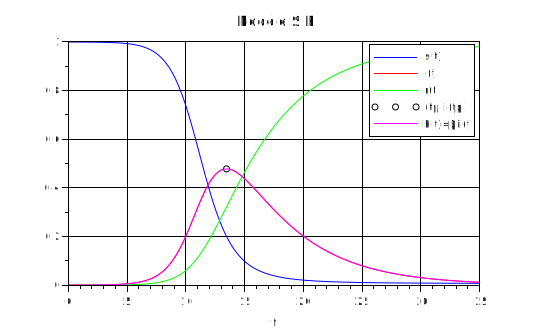

In [1]:
beta = 1;
gamma    = 0.2;

y0 = [1 - 1e-4, 1e-4, 0]';


function dydt = f(t, y)
    s = y(1);
    i = y(2);
    r = y(3);
    dydt = [-beta*s*i;
             beta*s*i - gamma*i;
             gamma*i];
endfunction


t = linspace(0, 35, 3500);
[t,y,info] = cvode(f, t, y0) ;

s_sol = y(1, :);
i_sol = y(2, :);
r_sol = y(3, :);


[imax, kmax] = max(i_sol);
tp = t(kmax);
printf("Pic épidémiologique : tp ≈ %.2f\n", tp);



clf();
plot(t, s_sol, 'b-');
plot(t, i_sol, 'r-');
plot(t, r_sol, 'g-');
plot(tp, imax, 'ko');
legend('s(t)', 'i(t)', 'r(t)', '(tp, i(tp))');
xlabel('t');
title('Modèle SIR');
xgrid();


// Condition d'épidémie : R0 * S(0) > N
R0 = beta / gamma;
S0 = y0(1);
printf("R0 = %.4f\n", R0);
printf("R0 * S(0) = %.4f\n", R0 * S0);

if R0 * S0 > 1 then
    printf("=> Epidemie confirmee : dI/dt(0) > 0\n");
else
    printf("=> Pas d''epidemie : dI/dt(0) <= 0\n");  // apostrophe doublée
end

dI_dt0 = (R0 * S0 - 1) * gamma * y0(2);
printf("dI/dt(0) = %.6f\n", dI_dt0);

// Force d'infection
F = beta * i_sol;
[Fmax, kFmax] = max(F);
printf("Force max : F = %.4f à t = %.2f\n", Fmax, t(kFmax));

// Ajouter F sur le graphique existant
plot(t, F, 'm-');
legend('s(t)', 'i(t)', 'r(t)', '(tp, i(tp))', 'F(t)=β·i(t)');


F est le taux de transmition entre le compartiment des individus  susceptibles et celui des individus infectés.

## Condition d'épidémie — Modèle SIR

Le **taux de reproduction de base** est défini par :

$$R_0 = \frac{\beta}{\gamma}$$

Il représente le nombre moyen de personnes contaminées par un individu infectieux.

---

En réécrivant l'équation sur les infectieux :

$$\frac{dI}{dt} = \left(R_0 \frac{S}{N} - 1\right) \gamma I$$

il en résulte que si $R_0 \cdot S(0) > N$, alors :

$$\frac{dI}{dt}(0) > 0$$

**Interprétation :**
- Si $\frac{dI}{dt}(0) > 0$ : l'épidémie se développe, les contaminations sont plus rapides que les guérisons.
- Si $\frac{dI}{dt}(0) \leq 0$ : les individus guérissent plus vite qu'ils ne contaminent, l'épidémie ne décolle pas.

---

Dans notre cas : $\beta = 1$, $\gamma = 0.2$, donc $R_0 = 5$ et $R_0 \cdot S(0) \approx 4.9995 > 1$ ✓

## The SIR model with vital dynamics and constant population

Consider a population characterized by a death rate $\mu$ and birth rate $\Lambda$, and where a communicable disease is spreading.

The model with mass-action transmission is:
$$
\frac{dS}{dt} = \Lambda - \mu S - \beta \cdot I S \\
\frac{dI}{dt} = \beta \cdot I S - \gamma I - \mu I \\
\frac{dR}{dt} = \gamma I - \mu R
$$

 s_theo  = 
   0.4
 i_theo  = 
   0.5500000
 r_theo  = 
   0.5500000
Pic épidémiologique : tp ≈ 12.86
Proportion final de personnes pouvant être infectées : 0.40
Proportion final de personnes infectées : 0.55
Proportion final de personne guéris ou décédées : 0.55


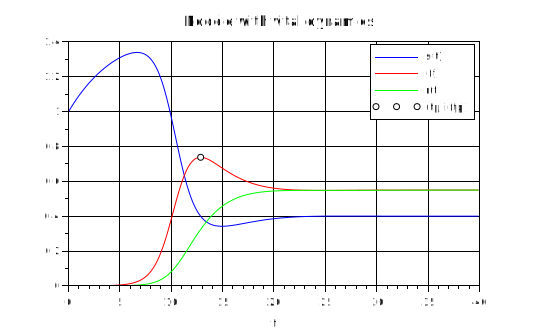

In [2]:
// beta : taux d'infection
// gamma : taux de guerison

beta = 1;
gamma = 0.2;
birth_rate = 0.3;
death_rate = 0.2;

R0 = (beta) / (death_rate + gamma) * (birth_rate / death_rate);
s_theo = ((gamma + death_rate)/beta)
i_theo = ((death_rate/beta)*(R0-1))
r_theo = (gamma/beta) * (R0 - 1)


y0 = [1 - 1e-4, 1e-4, 0]';


function dydt = f(t, y)
    s = y(1);
    i = y(2);
    r = y(3);
    dydt = [-beta*s*i - death_rate*s + birth_rate;
             beta*s*i - gamma*i - death_rate*i;
             gamma*i - death_rate*r];
endfunction

t_max = 500;
n = 3500;
t = linspace(0, t_max, n);
[t,y] = cvode(f, t, y0) ;

idx_max = round(40 * n / t_max);
tplot = t(1:idx_max);
yplot = y(:, 1:idx_max);

s_sol = yplot(1, :);
i_sol = yplot(2, :);
r_sol = yplot(3, :);

[imax, kmax] = max(i_sol);
tp = tplot(kmax);
printf("Pic épidémiologique : tp ≈ %.2f\n", tp);


clf();

plot(tplot, s_sol, 'b-');
plot(tplot, i_sol, 'r-');
plot(tplot, r_sol, 'g-');
plot(tp, imax, 'ko');
legend('s(t)', 'i(t)', 'r(t)', '(tp, i(tp))');
xlabel('t');
title('Modèle with vital dynamics');
xgrid();

printf("Proportion final de personnes pouvant être infectées : %.2f\n", s_sol($));
printf("Proportion final de personnes infectées : %.2f\n", i_sol($));
printf("Proportion final de personne guéris ou décédées : %.2f\n", r_sol($));
// xs2pdf(gcf(), 'exercice3.pdf');

## Modèle SIS — Épidémiologie

Dans le modèle **SIS** (Susceptible → Infected → Susceptible), il n'y a que **2 compartiments** :
les individus **susceptibles** $S$ et les individus **infectés** $I$.

Contrairement au modèle SIR, les individus guéris redeviennent susceptibles — il n'y a **pas d'immunité**.

---

### Système d'équations

$$\begin{aligned}
\frac{dS}{dt} &= -\frac{\beta S I}{N} + \gamma I \\[10pt]
\frac{dI}{dt} &= \frac{\beta S I}{N} - \gamma I
\end{aligned}$$

où :
- $\beta$ est le taux de transmission
- $\gamma$ est le taux de guérison
- $N = S + I = \text{constante}$ (population totale conservée)

---

### Réduction à une seule équation

Puisque $\frac{dS}{dt} + \frac{dI}{dt} = 0$, on a $S + I = N$, donc $S = N - I$.

En substituant dans l'équation sur $I$ :

$$\frac{dI}{dt} = \frac{\beta (N-I) I}{N} - \gamma I = \left(\beta - \gamma\right)I - \frac{\beta}{N}I^2$$

---

### Condition d'épidémie

De même que pour le modèle SIR, on définit le taux de reproduction de base :

$$R_0 = \frac{\beta}{\gamma}$$

- Si $R_0 > 1$ : l'infection persiste et atteint un **équilibre endémique**
- Si $R_0 \leq 1$ : l'infection **disparaît** progressivement

### Équilibre endémique

À l'équilibre ($\frac{dI}{dt} = 0$, $I \neq 0$) :

$$I^* = N\left(1 - \frac{1}{R_0}\right) = N\cdot\frac{\gamma(\beta - \gamma)}{\beta \gamma} $$

$$S^* = \frac{N}{R_0} = \frac{\gamma N}{\beta}$$

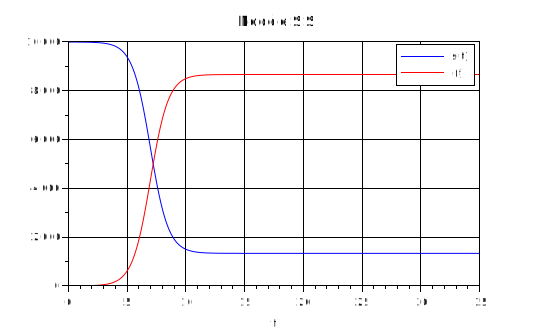

In [4]:
beta = 1.5;
gamma    = 0.2;
N = 10000 ; // il y'a 10 000 personnes dans l'expérience
y0 = [N-1, 1]';


function dydt = f(t, y)
    s = y(1);
    i = y(2);
    dydt = [-beta*s*i/N + gamma*i;
             beta*s*i/N - gamma*i]
endfunction


t = linspace(0, 35, 3500);
[t,y,info] = cvode(f, t, y0) ;

s_sol = y(1, :);
i_sol = y(2, :);

clf();
plot(t, s_sol, 'b-');
plot(t, i_sol, 'r-');
legend('s(t)', 'i(t)');
xlabel('t');
title('Modèle SIS');
xgrid();


## Modèle SEIR — Épidémiologie

Dans le modèle **SEIR** (Susceptible → Exposed → Infected → Recovered),
il y a **4 compartiments**. Par rapport au modèle SIR, une phase **d'exposition**
$E$ est ajoutée : une personne contaminée n'est pas immédiatement infectieuse,
elle traverse d'abord une **période de latence** durant laquelle elle peut
potentiellement développer la maladie.

---

### Système d'équations

$$\begin{aligned}
\frac{dS}{dt} &= \mu N - \mu S - \frac{\beta I S}{N} \\[10pt]
\frac{dE}{dt} &= \frac{\beta I S}{N} - (\mu + a)E \\[10pt]
\frac{dI}{dt} &= aE - (\gamma + \mu)I \\[10pt]
\frac{dR}{dt} &= \gamma I - \mu R
\end{aligned}$$

où :
- $\beta$ est le taux de transmission
- $a$ est le taux de passage de l'état exposé à infectieux ($1/a$ = durée de latence)
- $\gamma$ est le taux de guérison
- $\mu$ est le taux de natalité/mortalité (supposés égaux)

---

### Conservation de la population

Sous l'hypothèse que les taux de natalité et de mortalité sont égaux :

$$S + E + I + R = N = \text{constante}$$

---

### Taux de reproduction de base

$$R_0 = \frac{a\beta}{(\mu + a)(\mu + \gamma)}$$

**Interprétation :**
- $\frac{a}{\mu + a}$ : probabilité qu'un individu exposé devienne effectivement infectieux
- $\frac{\beta}{\mu + \gamma}$ : nombre de transmissions durant la période infectieuse

Ainsi :
- Si $R_0 > 1$ : l'épidémie se développe
- Si $R_0 \leq 1$ : l'infection disparaît progressivement

R0 = 4.3290
Pic epidemique : I = 2867.03 personnes a t = 64.97


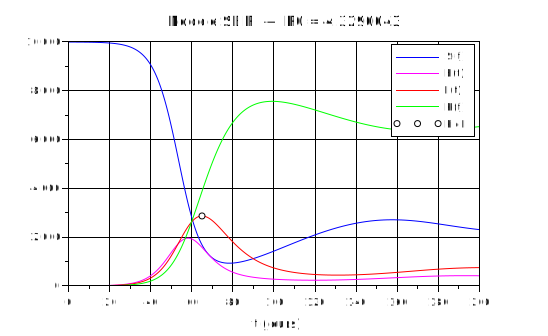

In [5]:
beta  = 0.5;
gamma = 0.1;
mu    = 0.01;
a     = 0.2;
N     = 10000;

y0 = [N - 1; 0; 1; 0];

function dydt = f(t, y)
    s = y(1);
    e = y(2);
    i = y(3);
    r = y(4);
    dydt = [mu*N - mu*s - beta*i*s/N;
            beta*i*s/N - (mu + a)*e;
            a*e - (gamma + mu)*i;
            gamma*i - mu*r];
endfunction

t = linspace(0, 200, 10000);
[t, y] = cvode(f, t, y0);

s_sol = y(1, :);
e_sol = y(2, :);
i_sol = y(3, :);
r_sol = y(4, :);

R0 = (a * beta) / ((mu + a) * (mu + gamma));
printf("R0 = %.4f\n", R0);

[imax, kmax] = max(i_sol);
tp = t(kmax);
printf("Pic epidemique : I = %.2f personnes a t = %.2f\n", imax, tp);

clf();
plot(t, s_sol, 'b-');
plot(t, e_sol, 'm-');
plot(t, i_sol, 'r-');
plot(t, r_sol, 'g-');
plot(tp, imax, 'ko');
legend('S(t)', 'E(t)', 'I(t)', 'R(t)', 'Pic I');
xlabel('t (jours)');
title('Modele SEIR  —  R0 = ' + string(R0));
xgrid();

## Modèle SIRV

"Susceptible-Infectious-Recovered-Vaccinated model"

$$
\frac{dS}{dt} = - \frac{\beta (t) \cdot I S}{N} - v(t) S\\
\frac{dI}{dt} = \frac{\beta (t) \cdot I S}{N} - \gamma (t) I  \\
\frac{dR}{dt} = \gamma (t) I \\
\frac{dV}{dt} = v(t)S
$$

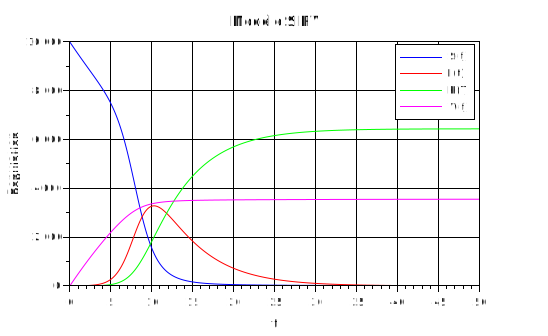

In [6]:
// SIRV MODEL

beta = 1.5;
gamma = 0.2;
N = 10000 ; // il y'a 10 000 personnes dans l'expérience
v = 0.05; // taux de vaccination


function dydt = f(t, y)
    S = y(1);
    I = y(2);
    R = y(3);
    V = y(4);
    dydt = [-beta*S*I/N - v*S;
             beta*S*I/N - gamma*I;
             gamma*I;
             v*S]
endfunction


t = linspace(0, 50, 3500);
y0 = [N - 1, 1, 0, 0]';

[t,y,info] = cvode(f, t, y0) ;

S_sol = y(1, :);
I_sol = y(2, :);
R_sol = y(3, :);
V_sol = y(4, :);

clf();
plot(t, S_sol, 'b-');
plot(t, I_sol, 'r-');
plot(t, R_sol, 'g-');
plot(t, V_sol, 'm-');
legend('S(t)', 'I(t)', 'R(T)', 'V(t)');
xlabel('t');
ylabel('Population')
title('Modèle SIRV');
xgrid();
